In [2]:
# At the very top of notebooks/1_data_extraction.ipynb
import sys, os
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk
# Insert project_root (one level up) onto the import path
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src"))
import numpy as np
import yaml
import matplotlib.pyplot as plt

In [1]:
# import evaluate
# roc_auc = evaluate.load("evaluate-metric/roc_auc") 
print("HF_HUB_OFFLINE =", os.environ.get("HF_HUB_OFFLINE"))


NameError: name 'os' is not defined

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src"))
import yaml
import evaluator
import importlib
importlib.reload(evaluator)

from variability_free_evaluation import evaluate_sample_predictions
from data_extractor import get_preprocessed_encode_cpg_dataframe ,create_length_window_id, create_labels_formultiple_instance_format_df, load_preprocessed_encode_cpg_dfs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.formatting import combine_cpg_dfs

        


# result_file_path = "/sci/labs/michall/roeizucker/temp/token_cls_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_prediction_smoke_top5000_from_epoch1/epoch-1-step-4958/eval_predictions.csv.gitbackup"
# result_files_path = [
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-1-step-32382/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-2-step-64764/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-3-step-97146/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-4-step-129528/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-5-step-161910/eval_predictions.csv.gitbackup"
# ]


# variability_file_path = "/sci/labs/michall/roeizucker/temp/token_cls_datasets/_token_cls_Bladder-Epithelial_kmer/Z0000043F_per_varaint_variability_token_cls_Bladder-Epithelial_kmer_seq_5400_datasets.csv"
result_files_path = '''/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-1-step-16887/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-2-step-33774/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-3-step-50661/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-4-step-67548/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-5-step-84435/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-6-step-101322/eval_predictions.csv.gitbackup'''.split("\n")
chroms = ["chr1","chr2","chr3","chr4","chr5","chr18","chr19","chr20","chr21","chr22"]
comparison_bigiwg_files = [
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652234_Liver-Hepatocytes-Z000000T3.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652235_Liver-Hepatocytes-Z0000043Q.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652236_Liver-Hepatocytes-Z0000044H.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652237_Liver-Hepatocytes-Z0000044M.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652238_Liver-Hepatocytes-Z00000431.hg38.bigwig"
]

full_pos_name = "full_pos"
ranges = [0,0.2,0.8,1]
labels = [0,1,2]

label_a = "mean_label"
label_b = "predicted_class"
number_of_bins = 5


# eval_objects_dict = evaluate_sample_predictions(variability_file_path, result_files_path, chroms, comparison_bigiwg_files, full_pos_name, ranges, labels, label_a, label_b, number_of_bins)
eval_objects_dict = evaluate_sample_predictions(result_files_path, chroms, comparison_bigiwg_files, full_pos_name, ranges, labels, [label_a, label_b],True)
print(eval_objects_dict)
    # break


# from src.evaluator import perform_evaluation
# path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/_after_revert_without_-1/eval_configs/3Q_epoch-1-step-32917_eval_after_revert_without_-1_other_dataset5.yaml"
# cfg = yaml.safe_load(open(path))
# cfg["task"]["top_rows"] = 200
# cfg["paths"]["model_paths"] = cfg["paths"]["model_paths"][1:2]
# # print(cfg)
# cfg["paths"]["model_path"] = cfg["paths"]["model_paths"][0]
# cfg['task']['sub_task'] = 'predict_single_checkpoint'
# cfg['model']["is_lora"] = False
# cfg['task']['use_variant_file'] = False
# pred = perform_evaluation(cfg)


curr result file /sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-1-step-16887/eval_predictions.csv.gitbackup


/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


curr result file /sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-2-step-33774/eval_predictions.csv.gitbackup


/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

curr result file /sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-3-step-50661/eval_predictions.csv.gitbackup


...

curr result file /sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-5-step-84435/eval_predictions.csv.gitbackup


/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

curr result file /sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-6-step-101322/eval_predictions.csv.gitbackup


/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

{'/sci/labs/michall/roeizucker/cls_downsample_liver/Z000000R3_epoch-3-step-254955_retrain_token_cls_Liver-Hepatocytes_kmer_lr_1e-06_bs_14_seq_5400/epoch-1-step-16887/eval_predictions.csv.gitbackup': {'all_results': {'mean_label': {0: {'Precision': 0.7542720938760543, 'recall': 0.6877347450543326}, 1: {'Precision': 0.7386070067837561, 'recall': 0.7837407432972104}, 2: {'Precision': 0.9257552670475494, 'recall': 0.9084058624346214}}, 'mean_label_confusion_matrix': {0: {0: 61707, 1: 18611, 2: 1492}, 1: {0: 27223, 1: 476889, 2: 141548}, 2: {0: 795, 1: 112978, 2: 1418632}}, 'predicted_class': {0: {'Precision': 0.7467853610286844, 'recall': 0.5721928113680691}, 1: {'Precision': 0.7174114531612049, 'recall': 0.6411308214923136}, 2: {'Precision': 0.8708201732846814, 'recall': 0.9185943014922467}}, 'predicted_class_confusion_matrix': {0: {0: 51340, 1: 14651, 2: 2757}, 1: {0: 29294, 1: 390114, 2: 124372}, 2: {0: 9091, 1: 203713, 2: 1434543}}, 'all_two': {0: {'Precision': 0.0, 'recall': 0.0}, 1: 

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src"))
import yaml
import evaluator
importlib.reload(evaluator)

from evaluator import create_comparison_dicts, apply_create_means, apply_create_labels, create_result_file_mean_label, create_eval_object, create_result_file_mean_value
import importlib
from data_extractor import get_preprocessed_encode_cpg_dataframe ,create_length_window_id, create_labels_formultiple_instance_format_df, load_preprocessed_encode_cpg_dfs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.formatting import combine_cpg_dfs

        


variability_file_path = "/sci/labs/michall/roeizucker/temp/token_cls_datasets/_token_cls_Bladder-Epithelial_kmer/Z0000043F_per_varaint_variability_token_cls_Bladder-Epithelial_kmer_seq_5400_datasets.csv"
# result_file_path = "/sci/labs/michall/roeizucker/temp/token_cls_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_prediction_smoke_top5000_from_epoch1/epoch-1-step-4958/eval_predictions.csv.gitbackup"
# result_files_path = [
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-1-step-32382/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-2-step-64764/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-3-step-97146/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-4-step-129528/eval_predictions.csv.gitbackup",
#     "/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_no_pretraining_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-5-step-161910/eval_predictions.csv.gitbackup"
# ]

result_files_path = '''/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_epoch-2-step-260548_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-1-step-32382/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_epoch-2-step-260548_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-2-step-64764/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_epoch-2-step-260548_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-3-step-97146/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_epoch-2-step-260548_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-4-step-129528/eval_predictions.csv.gitbackup
/sci/labs/michall/roeizucker/kol_kore_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_epoch-2-step-260548_retrain_token_cls_Bladder-Epithelial_kmer_lr_1e-06_bs_1_seq_5400/epoch-5-step-161910/eval_predictions.csv.gitbackup'''.split("\n")
chroms = ["chr5"]
comparison_bigiwg_files = [
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652342_Bladder-Epithelial-Z000000QM.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652343_Bladder-Epithelial-Z000000QP.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652345_Bladder-Epithelial-Z0000044L.hg38.bigwig",
    "/sci/archive/michall/roeizucker/downloaded_datasets/GSM5652346_Bladder-Epithelial-Z00000450.hg38.bigwig",
]

full_pos_name = "full_pos"
ranges = [0,0.2,0.8,1]
labels = [0,1,2]

label_a = "mean_label"
label_b = "predicted_class"


variability_file = pd.read_csv(variability_file_path)
compare_dicts = create_comparison_dicts(comparison_bigiwg_files,chroms,full_pos_name)


variability_file = pd.read_csv(variability_file_path)
compare_dicts = create_comparison_dicts(comparison_bigiwg_files,chroms,full_pos_name)
for result_file_path in result_files_path:
    new_result_file = create_result_file_mean_value(result_file_path, compare_dicts)
    print(new_result_file)
    break
    # TODO: add variability filtering on new_result_file
    # eval_object = create_eval_object(new_result_file,label_a,label_b,labels)
    # print(eval_object)
# print(get_preprocessed_encode_cpg_dataframe(comparison_bigiwg_files[0],["chr5"]))


# from src.evaluator import perform_evaluation
# path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/_after_revert_without_-1/eval_configs/3Q_epoch-1-step-32917_eval_after_revert_without_-1_other_dataset5.yaml"
# cfg = yaml.safe_load(open(path))
# cfg["task"]["top_rows"] = 200
# cfg["paths"]["model_paths"] = cfg["paths"]["model_paths"][1:2]
# # print(cfg)
# cfg["paths"]["model_path"] = cfg["paths"]["model_paths"][0]
# cfg['task']['sub_task'] = 'predict_single_checkpoint'
# cfg['model']["is_lora"] = False
# cfg['task']['use_variant_file'] = False
# pred = perform_evaluation(cfg)


                       window_id  window_start  window_end  token_index  \
0       chr5:100002600-100008000     100002600   100008000           50   
1       chr5:100002600-100008000     100002600   100008000           59   
2       chr5:100002600-100008000     100002600   100008000          135   
3       chr5:100002600-100008000     100002600   100008000          256   
4       chr5:100002600-100008000     100002600   100008000          738   
...                          ...           ...         ...          ...   
287373   chr5:99997200-100002600      99997200   100002600           52   
287374   chr5:99997200-100002600      99997200   100002600          105   
287375   chr5:99997200-100002600      99997200   100002600          171   
287376   chr5:99997200-100002600      99997200   100002600          365   
287377   chr5:99997200-100002600      99997200   100002600          853   

        token_position_in_window  base_position_in_window  genomic_position  \
0                   

In [ ]:
def create_confusion_matrix_heatmap(label_a, label_b, title, df):
    confusion_matrix = pd.crosstab(df[label_a], df[label_b])

# 2. Plot using Seaborn heatmap
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')

# 3. Add labels and show plot
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(title)
    plt.show()
    
# create_confusion_matrix_heatmap("label", "mean_label", "mean confusion matrix", df)
# create_confusion_matrix_heatmap("label", "predicted_class", "predicted confusion matrix", df)

/tmp/ipykernel_2225037/4259101657.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_result_file["mean_label"] =  new_result_file.apply(lambda x: apply_create_labels(x,[0,0.2,0.8,1]),axis=1)


/tmp/ipykernel_2225037/4084860422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_result_file["label"] = new_result_file["label"].astype(int)


mean_label    0     1      2
label                       
0           724   388     17
1           279  7449   1985
2             0  3325  21205


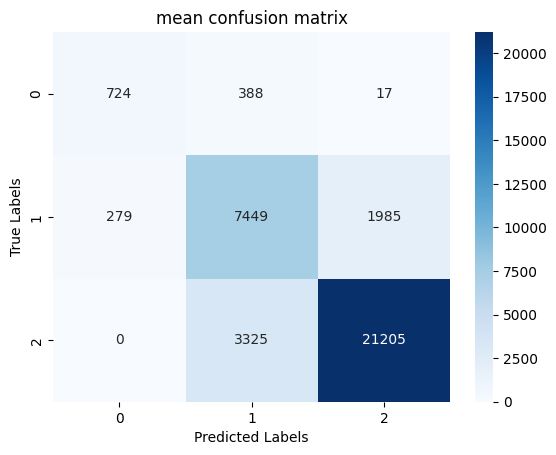

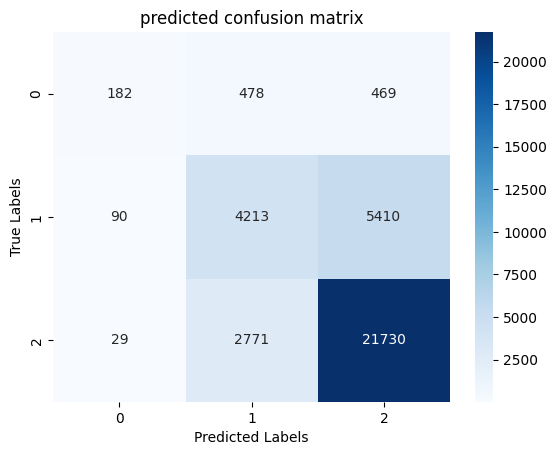

mean_label
	class 0
		Precision: 0.72
		Recall:    0.64
	class 1
		Precision: 0.67
		Recall:    0.77
	class 2
		Precision: 0.91
		Recall:    0.86
predicted_class
	class 0
		Precision: 0.60
		Recall:    0.16
	class 1
		Precision: 0.56
		Recall:    0.43
	class 2
		Precision: 0.79
		Recall:    0.89


/tmp/ipykernel_2225037/2562969022.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["specific_label"] = df["label"] == label
/tmp/ipykernel_2225037/2562969022.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["specific_mean_label"] = df[prediciton_type] == label
/tmp/ipykernel_2225037/2562969022.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

/tmp/ipykernel_2225037/1691070020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_result_file["specific_label"] = new_result_file["label"] == label


In [56]:
result_file

,window_id,window_start,window_end,token_index,token_position_in_window,base_position_in_window,genomic_position,label,prediction,logit,probability,predicted_class,logit_class_0,logit_class_1,logit_class_2,probability_class_0,probability_class_1,probability_class_2,chrom,mean_value
0,chr5:100002600-100008000,100002600,100008000,50,49,294,100002894,2.0,2,1.875000,0.774165,2,-2.765625,0.609375,1.875000,0.007472,0.218363,0.774165,chr5,0.975220
1,chr5:100002600-100008000,100002600,100008000,59,58,348,100002948,2.0,2,2.750000,0.955577,2,-2.984375,-0.390625,2.750000,0.003089,0.041334,0.955577,chr5,0.969482
2,chr5:100002600-100008000,100002600,100008000,135,134,804,100003404,1.0,1,1.125000,0.829228,1,-1.062500,1.125000,-1.242188,0.093037,0.829228,0.077735,chr5,0.363220
3,chr5:100002600-100008000,100002600,100008000,256,255,1530,100004130,1.0,1,0.804688,0.549688,1,-2.765625,0.804688,0.570312,0.015472,0.549688,0.434839,chr5,0.901978
4,chr5:100002600-100008000,100002600,100008000,738,737,4422,100007022,1.0,1,1.210938,0.783547,1,-1.757812,1.210938,-0.281250,0.040249,0.783547,0.176204,chr5,0.799072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36853,chr5:124432200-124437600,124432200,124437600,44,43,258,124432458,1.0,2,1.046875,0.698745,2,-2.546875,0.139648,1.046875,0.019212,0.282043,0.698745,chr5,0.832764
36854,chr5:124432200-124437600,124432200,124437600,162,161,966,124433166,2.0,2,2.125000,0.939115,2,-3.218750,-0.687500,2.125000,0.004487,0.056398,0.939115,chr5,0.909790
36855,chr5:124432200-124437600,124432200,124437600,538,537,3222,124435422,2.0,2,1.078125,0.583231,2,-2.875000,0.714844,1.078125,0.011195,0.405574,0.583231,chr5,0.895508
36856,chr5:124432200-124437600,124432200,124437600,627,626,3756,124435956,2.0,2,1.093750,0.618065,2,-2.671875,0.574219,1.093750,0.014310,0.367625,0.618065,chr5,0.965088


In [10]:
import os
import pandas as pd
# base_path = "/sci/labs/michall/roezucker/kol_kore_results/to_download2/to_download/"
base_path = "/sci/labs/michall/roeizucker/copy_old_models"
# base_path = "/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_revengence_Liver-Hepatocytes_kmer"
# base_path = "/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_3/_kol_kora_high_only_Liver-Hepatocytes_kmer/"
base_path = "/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_4/_kol_kora_high_only_Liver-Hepatocytes_kmer"
best_name = ""
best_len = 0
highest = 0
all_result = {}
for dir_name in os.listdir(base_path):
    if "kmer" in dir_name:
        sample_name = (dir_name.split("_")[0])
        variability_path = f"/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/{sample_name}_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv"
        # print(variability_path)
        # print(dir_name)
        df_variability = None
        curr_path = os.path.join(base_path,dir_name)
        for epoch_dir in os.listdir(curr_path):
            
            data_path = os.path.join(curr_path,epoch_dir,"eval_predictions.csv.gitbackup")
            if epoch_dir.startswith("checkpoint") or not os.path.exists(data_path):
                continue

            if (int(epoch_dir.split("-")[1])) < 29:
                continue

            if df_variability is None:
                df_variability = pd.read_csv(variability_path)
            df_data = pd.read_csv(data_path)
            df_data["chr"] = df_data["window_id"].str.split(":").str[0]
            df_data["full_position"] = df_data["chr"] + ":" + df_data["genomic_position"].astype(str) + "-"+ (df_data["genomic_position"] + 2).astype(str)
            std_max = df_variability["std"].max()
            results = []
            target = 5
            print(data_path)
            for i in range(target):
                low = (std_max/target) * i
                high = (std_max/target) * (i+1)
                filtered = df_variability[(df_variability["std"] > low) & (df_variability["std"] <= high)]
                positions = set(filtered["full_position"])
                filtered_data = df_data[df_data["full_position"].isin(positions)]
                print(low,"-",high)
                corr = filtered_data[["label","prediction"]].corr().iloc[0,1]
                results.append(corr)

                print(corr,len(filtered_data))
                if (i +1)== target and  corr > highest:
                    best_name = data_path
                    best_len = len(filtered_data)
                    highest = corr
            print("curr_high:",highest,best_len,best_name)
            all_result[data_path] = results

/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_4/_kol_kora_high_only_Liver-Hepatocytes_kmer/Z0000043Q_epoch-1-step-67548_retrain_kol_kora_high_only_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.3/epoch-29-step-389876/eval_predictions.csv.gitbackup
0.0 - 0.10740000000000001
0.7769489764528204 346986
0.10740000000000001 - 0.21480000000000002
0.5115247453554005 61255
0.21480000000000002 - 0.32220000000000004
0.32886916056214655 10204
0.32220000000000004 - 0.42960000000000004
0.21050855395480564 2175
0.42960000000000004 - 0.537
-0.11102056947069637 144
curr_high: 0 0 
/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_4/_kol_kora_high_only_Liver-Hepatocytes_kmer/Z0000043Q_epoch-1-step-67548_retrain_kol_kora_high_only_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.3/epoch-30-step-403320/eval_predictions.csv.gitbackup
0.0 - 0.10740000000000001
0.7767153770570832 346986
0.10740000000000001 - 0.21480000000000002
0.51119395099

In [ ]:
# base_path = "/sci/labs/michall/roeizucker/kol_kore_results/to_download2/to_download/"
base_path = "/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_3/_kol_kora_high_only_Liver-Hepatocytes_kmer/"
# base_path = "/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_revengence_Liver-Hepatocytes_kmer"
best_name = ""
best_len = 0
highest = 0
all_result = {}
for dir_name in os.listdir(base_path):
    if "kmer" in dir_name:
        sample_name = (dir_name.split("_")[0])
        variability_path = f"/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/{sample_name}_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv"
        # print(variability_path)
        # print(dir_name)
        df_variability = None
        curr_path = os.path.join(base_path,dir_name)
        for epoch_dir in os.listdir(curr_path):
            data_path = os.path.join(curr_path,epoch_dir,"eval_predictions.csv.gitbackup")
            if epoch_dir.startswith("checkpoint") or not os.path.exists(data_path):
                continue
            
            if df_variability is None:
                df_variability = pd.read_csv(variability_path)
            df_data = pd.read_csv(data_path)
            df_data["chr"] = df_data["window_id"].str.split(":").str[0]
            df_data["full_position"] = df_data["chr"] + ":" + df_data["genomic_position"].astype(str) + "-"+ (df_data["genomic_position"] + 2).astype(str)
            std_max = df_variability["std"].max()
            results = []
            target = 5
            print(data_path)
            for i in range(target):
                low = (std_max/target) * i
                high = (std_max/target) * (i+1)
                filtered = df_variability[(df_variability["std"] > low) & (df_variability["std"] <= high)]
                positions = set(filtered["full_position"])
                filtered_data = df_data[df_data["full_position"].isin(positions)]
                print(low,"-",high)
                corr = filtered_data[["label","prediction"]].corr().iloc[0,1]
                results.append(corr)
                
                print(corr,len(filtered_data))
                if (i +1)== target and  corr > highest:
                    best_name = data_path
                    best_len = len(filtered_data)
                    highest = corr
            print("curr_high:",highest,best_len,best_name)
            all_result[data_path] = results

/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_3/_kol_kora_high_only_Liver-Hepatocytes_kmer/Z0000043Q_epoch-1-step-67548_retrain_kol_kora_high_only_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.3/epoch-8-step-107552/eval_predictions.csv.gitbackup
0.0 - 0.10740000000000001
0.770679445742912 346986
0.10740000000000001 - 0.21480000000000002
0.5043501611151865 61255
0.21480000000000002 - 0.32220000000000004
0.318120265839826 10204
0.32220000000000004 - 0.42960000000000004
0.20262957632505824 2175
0.42960000000000004 - 0.537
-0.027586684948547786 144
curr_high: 0 0 
/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_3/_kol_kora_high_only_Liver-Hepatocytes_kmer/Z0000043Q_epoch-1-step-67548_retrain_kol_kora_high_only_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.3/epoch-10-step-134440/eval_predictions.csv.gitbackup
0.0 - 0.10740000000000001
0.7705833838807432 346986
0.10740000000000001 - 0.21480000000000002
0.50409885965138

KeyboardInterrupt: 

In [6]:
with open("temp_res.txt","w") as f:
    f.write(str(all_result))

In [2]:
import json
import ast

with open("temp_res.txt","r") as f:
    dic = ((ast.literal_eval(f.read())))

In [77]:
no_pretraining_high_only_dict_5400 = {}
for key in dic:
    if "high" not in key:
        continue
    if key.split("_")[18] != "5400":
        continue
    if key.split("_")[8] != "no":
        continue
    name = key.split("_")[7].split("/")[1]
    step = key.split("_")[22].split("/")[1].split("-step-")[0]
    # print(step)
    if step not in no_pretraining_high_only_dict_5400:
        no_pretraining_high_only_dict_5400[step] = []
    no_pretraining_high_only_dict_5400[step].append(dic[key])
    # print(list(enumerate(key.split("_"))))
    # break
import numpy as np
avaraged = {}
for key in no_pretraining_high_only_dict_5400:
    avaraged[key] = (np.array(no_pretraining_high_only_dict_5400[key]).mean(axis=0))
    # break
vals = sorted(avaraged.items(),key=lambda x:int(x[0].split("-")[1]))

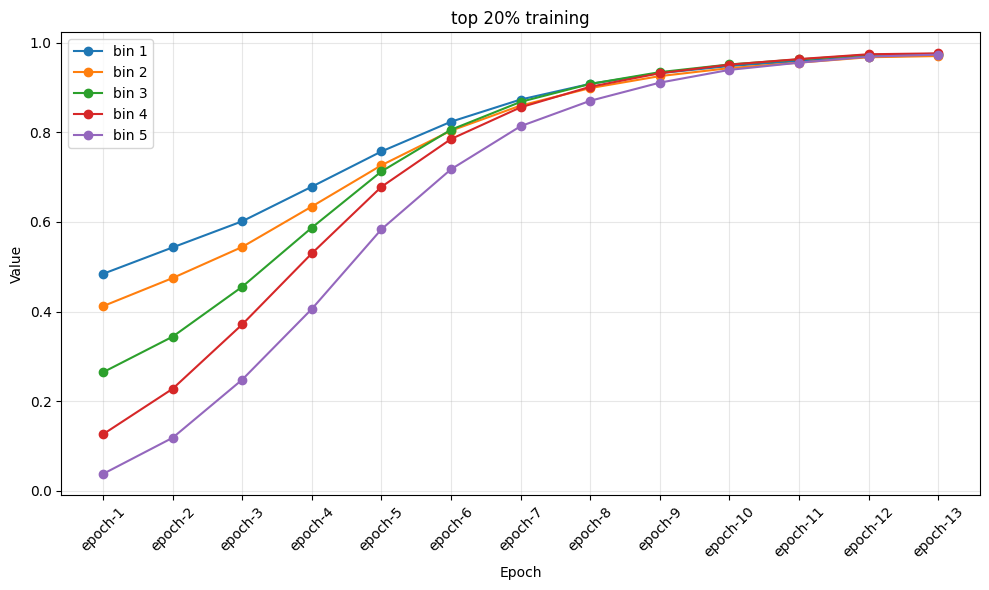

In [87]:
data = vals
epochs = [label for label, _ in data]
values = np.vstack([arr for _, arr in data])  # shape: (13, 5)

plt.figure(figsize=(10, 6))

for i in range(values.shape[1]):
    plt.plot(epochs, values[:, i], marker='o', label=f'bin {i+1}')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("top 20% training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [88]:
no_pretraining_dict_5400 = {}
for key in dic:

    if "high" in key:
        continue
    if key.split("_")[18] != "5400":
        continue
    if key.split("_")[8] != "no":
        continue
    # print(key)
    # print(list(enumerate(key.split("_"))))
    name = key.split("_")[7].split("/")[1]
    step = key.split("_")[20].split("/")[1].split("-step-")[0]
    # print(step)
    if step not in no_pretraining_high_only_dict_5400:
        no_pretraining_high_only_dict_5400[step] = []
    no_pretraining_high_only_dict_5400[step].append(dic[key])
    # break
import numpy as np
avaraged = {}
for key in no_pretraining_high_only_dict_5400:
    avaraged[key] = (np.array(no_pretraining_high_only_dict_5400[key]).mean(axis=0))
    # break
vals = sorted(avaraged.items(),key=lambda x:int(x[0].split("-")[1]))

In [91]:
vals

[('epoch-1',
  array([0.56315679, 0.39172372, 0.23254622, 0.0879691 , 0.03031259])),
 ('epoch-2',
  array([0.60917026, 0.44322799, 0.29269226, 0.16205015, 0.07890684])),
 ('epoch-3',
  array([0.6535657 , 0.49734395, 0.37156162, 0.26121598, 0.15068548])),
 ('epoch-4',
  array([0.7021132 , 0.55803232, 0.46154354, 0.37266382, 0.24071002])),
 ('epoch-5',
  array([0.74583297, 0.60959557, 0.53268732, 0.45769837, 0.33993166])),
 ('epoch-6',
  array([0.7907833 , 0.66897833, 0.60623238, 0.5413272 , 0.42133366])),
 ('epoch-7',
  array([0.8299538 , 0.71715623, 0.66415507, 0.60662638, 0.49136729])),
 ('epoch-8',
  array([0.85760073, 0.75245903, 0.70304556, 0.65050476, 0.53554258])),
 ('epoch-9',
  array([0.87722177, 0.77853233, 0.73057259, 0.68131245, 0.56783277])),
 ('epoch-10',
  array([0.89089481, 0.79746938, 0.75064099, 0.70344396, 0.59191594])),
 ('epoch-11',
  array([0.9013215 , 0.81187703, 0.76480826, 0.71923952, 0.6071014 ])),
 ('epoch-12',
  array([0.89812256, 0.7961036 , 0.73940064, 0.68

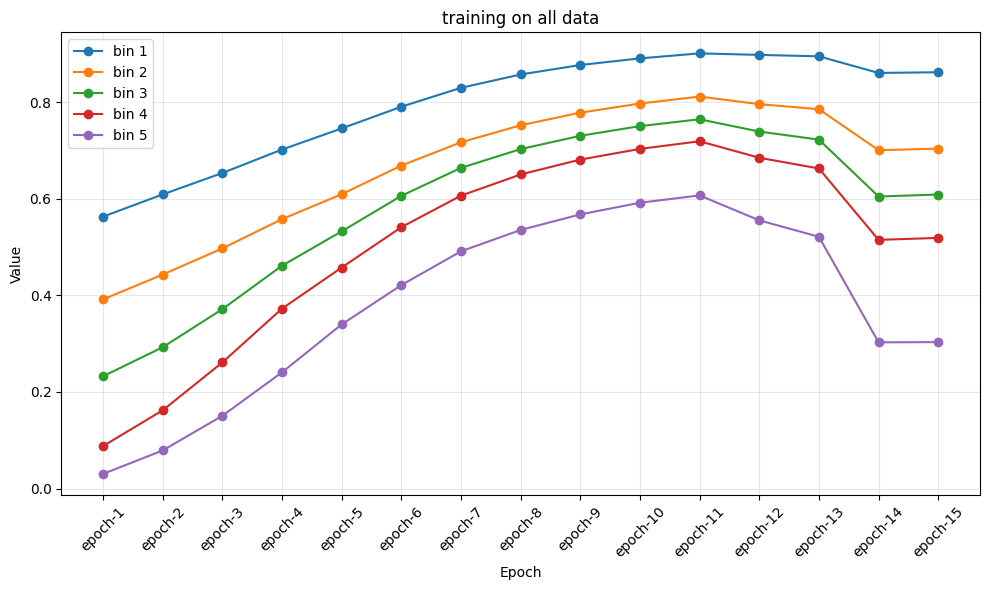

In [90]:
data = vals
epochs = [label for label, _ in data]
values = np.vstack([arr for _, arr in data])  # shape: (13, 5)

plt.figure(figsize=(10, 6))

for i in range(values.shape[1]):
    plt.plot(epochs, values[:, i], marker='o', label=f'bin {i+1}')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("training on all data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [73]:
import pandas as pd
df = pd.read_csv("/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_revengence_Liver-Hepatocytes_kmer/Z000000R3_epoch-1-step-60582_retrain_revengence_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2/epoch-1-step-8998/eval_predictions.csv.gitbackup")

In [6]:
df 

NameError: name 'df' is not defined

In [ ]:
for val in sorted(list(all_result.items()),key=lambda x:-x[1][0]):
    
    print(val)

('/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_Liver-Hepatocytes_kmer/Z00000431_no_pretraining_retrain_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2_high_only/epoch-12-step-122004/eval_predictions.csv.gitbackup', [0.9767102283963316, 0.9761445843444003, 0.9819824253325242, 0.9850156401922614, 0.9807785602884715])
('/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_Liver-Hepatocytes_kmer/Z000000R3_no_pretraining_retrain_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2_high_only/epoch-13-step-128024/eval_predictions.csv.gitbackup', [0.9756051904052342, 0.9736355277736003, 0.9773352950326462, 0.9764714907798119, 0.9712289085027093])
('/sci/labs/michall/roeizucker/copy_old_models/trained_huggingface_models_location/_Liver-Hepatocytes_kmer/Z000000R3_no_pretraining_retrain_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2_high_only/epoch-12-step-118176/eval_predictions.csv.gitbackup', [0.9

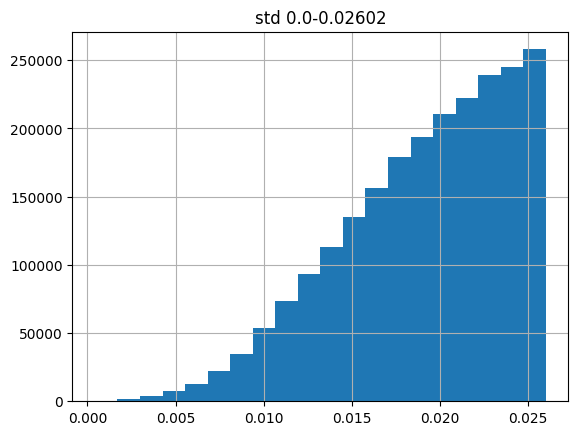

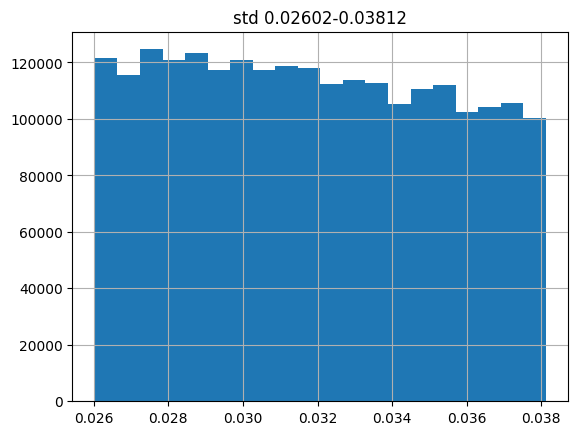

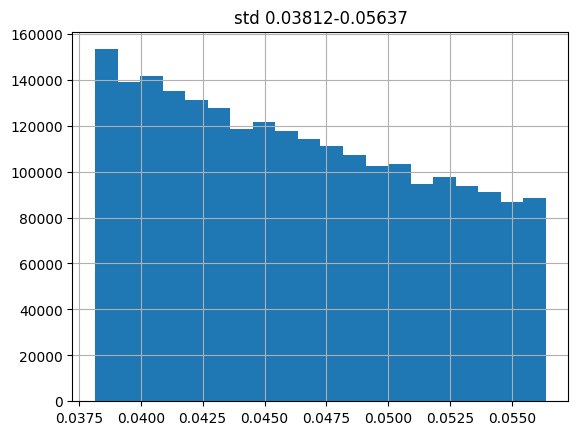

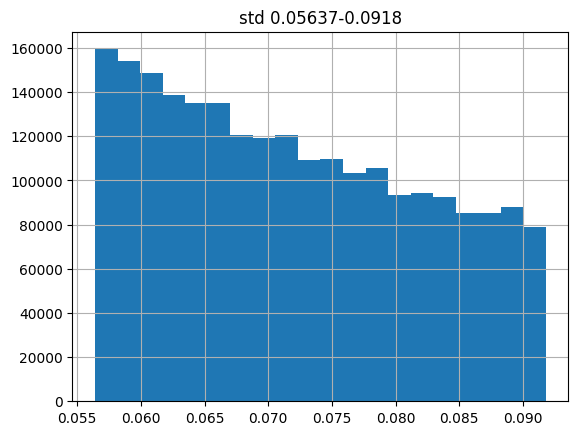

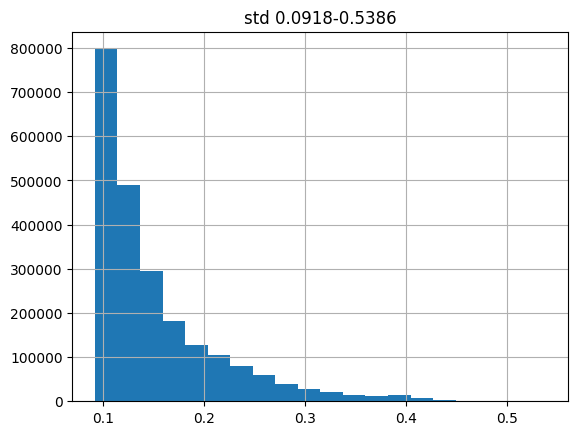

In [ ]:
base_path = "/sci/labs/michall/roeizucker/kol_kore_results/to_download2/to_download/" 
values = []
for dir_name in os.listdir(base_path):
    if "5400" in dir_name and "kmer" in dir_name:
        sample_name = (dir_name.split("_")[0])
        variability_path = f"/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/{sample_name}_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv"
        # print(variability_path)
        # print(dir_name)
        df_variability = pd.read_csv(variability_path)
        target = 5
        quantile_vals = []
        for i in range(target + 1):
            quantile_vals.append(df_variability["std"].quantile((1/target) * i))
        for i in range(target):
            # low = (std_max/target) * i
            # high = (std_max/target) * (i+1)
            low = quantile_vals[i]
            high = quantile_vals[i+1]
            filtered = df_variability[(df_variability["std"] > low) & (df_variability["std"] <= high)]
            filtered["std"].hist(bins=20)
            plt.title(f"std {low}-{high}")
            plt.show()
    break
            

In [1]:
# base_path = "/sci/labs/michall/roeizucker/kol_kore_results/to_download2/to_download/" 
base_path = "/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_3/_kol_kora_high_only_Liver-Hepatocytes_kmer/" 
values = []
for dir_name in os.listdir(base_path):
    if "5400" in dir_name and "kmer" in dir_name:
        sample_name = (dir_name.split("_")[0])
        variability_path = f"/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/{sample_name}_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv"
        # print(variability_path)
        # print(dir_name)
        df_variability = pd.read_csv(variability_path)
        curr_path = os.path.join(base_path,dir_name)
        print(dir_name)
        for epoch_dir in os.listdir(curr_path):
            if "epoch-5" not in epoch_dir:
                continue
            print(epoch_dir)
            data_path = os.path.join(curr_path,epoch_dir,"eval_predictions.csv.gitbackup")
            df_data = pd.read_csv(data_path)
            df_data["chr"] = df_data["window_id"].str.split(":").str[0]
            df_data["full_position"] = df_data["chr"] + ":" + df_data["genomic_position"].astype(str) + "-"+ (df_data["genomic_position"] + 2).astype(str)
            print(df_data[["label","prediction"]].corr()["prediction"][0])
            values.append(df_data[["label","prediction"]].corr()["prediction"][0])
            std_max = df_variability["std"].max()
            target = 5
            quantile_vals = []
            quantile = False
            for i in range(target + 1):
                quantile = True
                quantile_vals.append(df_variability["std"].quantile((1/target) * i))
            df_data[["label","prediction"]].plot.hexbin("label","prediction",bins='log')
            plt.show()
            # assert False
            for i in range(target):
                # low = (std_max/target) * i
                # high = (std_max/target) * (i+1)
                low = quantile_vals[i]
                high = quantile_vals[i+1]
                filtered = df_variability[(df_variability["std"] > low) & (df_variability["std"] <= high)]
                positions = set(filtered["full_position"])
                filtered_data = df_data[df_data["full_position"].isin(positions)]
                filtered_data[["label","prediction"]].plot.hexbin("label","prediction",bins='log')
                title = f"{low}-{high}"
                if quantile:
                    title += f" quantile {i}"
                else:
                    title += f" bin {i}"
                plt.title(title)
                plt.show()
                # print(high)
                # # print(filtered_data[["label","prediction"]].corr())
                # mae = (filtered_data['label'] - filtered_data['prediction']).abs().mean()
                # print(mae)

                # filtered_data[["label"]].hist(bins=20)
                # plt.title(f"label {low}-{high}")
                # plt.show()
                # filtered_data[["prediction"]].hist(bins=20)
                # plt.title(f"prediction {low}-{high}")
                # plt.show()
            break

                

NameError: name 'os' is not defined

In [9]:
sum(values)/ len(values)

0.766885060415191

In [ ]:
epoch_dirs = "epoch-1-step-8991/  epoch-2-step-17982/  epoch-3-step-26973/  epoch-4-step-35964/  epoch-5-step-44955/".split("  ")
for epoch_dir in epoch_dirs:
    print(epoch_dir)
    df_data = pd.read_csv(f"/sci/labs/michall/roeizucker/kol_kore_results/to_download2/to_download/Z0000044M_epoch-1-step-41984_retrain_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2/{epoch_dir}eval_predictions.csv.gitbackup")
    # df_data = pd.read_csv(f"/sci/labs/michall/roeizucker/kol_kore_results/to_download2/to_download/Z0000044M_no_pretraining_retrain_Liver-Hepatocytes_kmer_lr_1e-06_bs_64_seq_5400_testsize_0.2/{epoch_dir}eval_predictions.csv.gitbackup")
    df_variability = pd.read_csv("/sci/labs/michall/roeizucker/huggingface_datasets_dir/huggingface_datasets_dir/_Liver-Hepatocytes_kmer/Z0000044M_per_varaint_variability_Liver-Hepatocytes_kmer_seq_5400_datasets.csv")
    df_data["chr"] = df_data["window_id"].str.split(":").str[0]
    df_data["full_position"] = df_data["chr"] + ":" + df_data["genomic_position"].astype(str) + "-"+ (df_data["genomic_position"] + 2).astype(str)
    std_max = df_variability["std"].max()
    target = 5
    for i in range(target):
        low = (std_max/target) * i
        high = (std_max/target) * (i+1)
        filtered = df_variability[(df_variability["std"] > low) & (df_variability["std"] <= high)]
        positions = set(filtered["full_position"])
        filtered_data = df_data[df_data["full_position"].isin(positions)]
        print(high)
        print(filtered_data[["label","prediction"]].corr())


epoch-1-step-8991/
0.10772
               label  prediction
label       1.000000    0.736144
prediction  0.736144    1.000000
0.21544
               label  prediction
label       1.000000    0.399961
prediction  0.399961    1.000000
0.32316
               label  prediction
label       1.000000    0.230879
prediction  0.230879    1.000000
0.43088
               label  prediction
label       1.000000    0.070965
prediction  0.070965    1.000000
0.5386
               label  prediction
label       1.000000    0.003768
prediction  0.003768    1.000000
epoch-2-step-17982/
0.10772
               label  prediction
label       1.000000    0.736148
prediction  0.736148    1.000000
0.21544
               label  prediction
label       1.000000    0.399705
prediction  0.399705    1.000000
0.32316
              label  prediction
label       1.00000     0.23027
prediction  0.23027     1.00000
0.43088
               label  prediction
label       1.000000    0.070871
prediction  0.070871    1.000000
0.

In [22]:
df_variability

,Unnamed: 0,full_position,window_id,std,high_diff
0,0,chr1:10468-10470,chr1:5400-10800,0.09430,True
1,1,chr1:10470-10472,chr1:5400-10800,0.07620,True
2,2,chr1:10483-10485,chr1:5400-10800,0.05978,True
3,3,chr1:10488-10490,chr1:5400-10800,0.13260,True
4,4,chr1:10492-10494,chr1:5400-10800,0.09560,True
...,...,...,...,...,...
11383451,11383451,chr22:50808221-50808223,chr22:50803200-50808600,0.10340,True
11383452,11383452,chr22:50808227-50808229,chr22:50803200-50808600,0.12286,True
11383453,11383453,chr22:50808233-50808235,chr22:50803200-50808600,0.11694,True
11383454,11383454,chr22:50808239-50808241,chr22:50803200-50808600,0.14270,True


In [21]:
df_data

,window_id,window_start,window_end,token_index,token_position_in_window,base_position_in_window,genomic_position,label,prediction,logit,probability,chr
0,chr18:10006200-10011600,10006200,10011600,92,91,546,10006746,0.524902,0.643329,0.589844,0.643329,chr18
1,chr18:10006200-10011600,10006200,10011600,102,101,606,10006806,0.666992,0.824462,1.546875,0.824462,chr18
2,chr18:10006200-10011600,10006200,10011600,106,105,630,10006830,0.844238,0.804406,1.414062,0.804406,chr18
3,chr18:10006200-10011600,10006200,10011600,118,117,702,10006902,0.471924,0.649579,0.617188,0.649579,chr18
4,chr18:10006200-10011600,10006200,10011600,125,124,744,10006944,0.710938,0.824462,1.546875,0.824462,chr18
...,...,...,...,...,...,...,...,...,...,...,...,...
6645498,chr5:99991800-99997200,99991800,99997200,828,827,4962,99996762,0.717773,0.728748,0.988281,0.728748,chr5
6645499,chr5:99991800-99997200,99991800,99997200,833,832,4992,99996792,0.853027,0.794385,1.351562,0.794385,chr5
6645500,chr5:99991800-99997200,99991800,99997200,851,850,5100,99996900,0.754883,0.795658,1.359375,0.795658,chr5
6645501,chr5:99991800-99997200,99991800,99997200,866,865,5190,99996990,0.333008,0.778649,1.257812,0.778649,chr5


In [26]:
df_data

,window_id,window_start,window_end,token_index,token_position_in_window,base_position_in_window,genomic_position,label,prediction,logit,probability,chr,full_position
0,chr18:10006200-10011600,10006200,10011600,92,91,546,10006746,0.524902,0.643329,0.589844,0.643329,chr18,chr18:10006746-10006748
1,chr18:10006200-10011600,10006200,10011600,102,101,606,10006806,0.666992,0.824462,1.546875,0.824462,chr18,chr18:10006806-10006808
2,chr18:10006200-10011600,10006200,10011600,106,105,630,10006830,0.844238,0.804406,1.414062,0.804406,chr18,chr18:10006830-10006832
3,chr18:10006200-10011600,10006200,10011600,118,117,702,10006902,0.471924,0.649579,0.617188,0.649579,chr18,chr18:10006902-10006904
4,chr18:10006200-10011600,10006200,10011600,125,124,744,10006944,0.710938,0.824462,1.546875,0.824462,chr18,chr18:10006944-10006946
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6645498,chr5:99991800-99997200,99991800,99997200,828,827,4962,99996762,0.717773,0.728748,0.988281,0.728748,chr5,chr5:99996762-99996764
6645499,chr5:99991800-99997200,99991800,99997200,833,832,4992,99996792,0.853027,0.794385,1.351562,0.794385,chr5,chr5:99996792-99996794
6645500,chr5:99991800-99997200,99991800,99997200,851,850,5100,99996900,0.754883,0.795658,1.359375,0.795658,chr5,chr5:99996900-99996902
6645501,chr5:99991800-99997200,99991800,99997200,866,865,5190,99996990,0.333008,0.778649,1.257812,0.778649,chr5,chr5:99996990-99996992


0.10772
               label  prediction
label       1.000000    0.724531
prediction  0.724531    1.000000
0.21544
               label  prediction
label       1.000000    0.472057
prediction  0.472057    1.000000
0.32316
               label  prediction
label       1.000000    0.338607
prediction  0.338607    1.000000
0.43088
              label  prediction
label       1.00000     0.19016
prediction  0.19016     1.00000
0.5386
               label  prediction
label       1.000000    0.106554
prediction  0.106554    1.000000


In [9]:
df_data[["label","prediction"]]

,label,prediction
0,0.524902,0.643329
1,0.666992,0.824462
2,0.844238,0.804406
3,0.471924,0.649579
4,0.710938,0.824462
...,...,...
6645498,0.717773,0.728748
6645499,0.853027,0.794385
6645500,0.754883,0.795658
6645501,0.333008,0.778649


In [11]:
df_data

,window_id,window_start,window_end,token_index,token_position_in_window,base_position_in_window,genomic_position,label,prediction,logit,probability
0,chr18:10006200-10011600,10006200,10011600,92,91,546,10006746,0.524902,0.643329,0.589844,0.643329
1,chr18:10006200-10011600,10006200,10011600,102,101,606,10006806,0.666992,0.824462,1.546875,0.824462
2,chr18:10006200-10011600,10006200,10011600,106,105,630,10006830,0.844238,0.804406,1.414062,0.804406
3,chr18:10006200-10011600,10006200,10011600,118,117,702,10006902,0.471924,0.649579,0.617188,0.649579
4,chr18:10006200-10011600,10006200,10011600,125,124,744,10006944,0.710938,0.824462,1.546875,0.824462
...,...,...,...,...,...,...,...,...,...,...,...
6645498,chr5:99991800-99997200,99991800,99997200,828,827,4962,99996762,0.717773,0.728748,0.988281,0.728748
6645499,chr5:99991800-99997200,99991800,99997200,833,832,4992,99996792,0.853027,0.794385,1.351562,0.794385
6645500,chr5:99991800-99997200,99991800,99997200,851,850,5100,99996900,0.754883,0.795658,1.359375,0.795658
6645501,chr5:99991800-99997200,99991800,99997200,866,865,5190,99996990,0.333008,0.778649,1.257812,0.778649


In [ ]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652237_Liver-Hepatocytes-Z0000044M_chr1_basic_test")
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")

In [13]:
top_rows = 50000
dataset_to_evaluate = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/31_pretrain_after_HPO_lr_06_bs_2_chr1-10_train").select(range(top_rows))
datasets_to_use = [
    load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_pretrain_after_HPO_lr_06_bs_2_chr1-10_train/").select(range(top_rows)),
    load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/4H_pretrain_after_HPO_lr_06_bs_2_chr1-10_train/").select(range(top_rows))
]

In [14]:
def create_window_id_dataset_dict(dataset):
    keys = []
    index = 0
    dataset_dict = {}
    for val in dataset:
        dataset_dict[val["window_id"]] = val
        keys.append(val["window_id"])
        index+=1
    return dataset_dict, keys

dataset_dict_to_evaluate, ordered_keys = create_window_id_dataset_dict(dataset_to_evaluate)
dataset_dicts_to_use = []
for dataset in datasets_to_use:
    dic,temp_keys = create_window_id_dataset_dict(dataset)
    dataset_dicts_to_use.append(dic)


In [15]:
dataset_to_evaluate

Dataset({
    features: ['seq', 'labels', 'start', 'end', 'window_id', 'input_ids', 'attention_mask'],
    num_rows: 50000
})

In [10]:
from evaluator import predict_checkpoint
prediction = predict_checkpoint(dataset_to_evaluate,dataset_to_evaluate,"regression_analysis",False,1,"InstaDeepAI",
                                "nucleotide-transformer-2.5b-multi-species","/sci/labs/michall/roeizucker/trained_huggingface_models_location/R3_manual/epoch-1-step-129373/")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2026-01-03 14:34:39.103059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-03 14:34:41.980552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-03 14:34:42.855525: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-03 14:34:47.602502: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-03 14:35:15.931099: W tensorflow/compiler/tf2

Loading model from: InstaDeepAI/nucleotide-transformer-2.5b-multi-species
with path: /sci/labs/michall/roeizucker/trained_huggingface_models_location/R3_manual/epoch-1-step-129373/


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

/sci/nosnap/michall/roeizucker/new_python_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


(901,)

In [13]:
predictions_copy = prediction.predictions.copy()

In [16]:
actual_labels = []
estimated_labels = []
for i in range(len(ordered_keys)):
    key = ordered_keys[i]
    window_to_eval = dataset_dict_to_evaluate[key]
    labels = np.array(window_to_eval["labels"])
    mask = labels != -100
    true_labels = labels[mask]

    other_vals = []
    added = False
    for dic in dataset_dicts_to_use:
        if key in dic:
            added = True
            other_vals.append(np.array(dic[key]["labels"])[mask])
    if not added:
        continue
    other_vals = np.array(other_vals)
    other_vals[other_vals == -100] = np.nan
    # print(np.nanmean(other_vals,axis=0))
    # print(raw_predictions[mask])
    actual_labels.extend(true_labels)
    estimated_labels.extend(np.nanmean(other_vals,axis=0))
    

/tmp/ipykernel_1027360/1770222982.py:23: RuntimeWarning: Mean of empty slice
  estimated_labels.extend(np.nanmean(other_vals,axis=0))


In [7]:
from  utils.metrics_utils import(
    pearsonr_eval,
    mse,
    mae
)

2026-06-07 19:24:59.445277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-07 19:25:01.943954: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-07 19:25:02.657579: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-07 19:25:06.813083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-07 19:25:33.763908: W tensorflow/compiler/tf2

In [17]:
np_actual_labels = np.array(actual_labels)
np_estimated_labels = np.array(estimated_labels)
mask = ~(np.isnan(np_actual_labels) | np.isnan(np_estimated_labels))


In [9]:
mask

array([ True,  True,  True, ...,  True,  True,  True])

In [18]:
pearsonr_eval.compute(predictions=np_actual_labels[mask],references=np_estimated_labels[mask])

{'pearsonr': 0.9487683049689657}

In [ ]:
# for index in range(len(dataset_to_evaluate)):
index = 0
if not index:
    curr_registry = dataset_to_evaluate[index]
    curr_window = curr_registry["window_id"]
    for dataset in datasets_to_use:
        positive_reviews = dataset.filter(lambda example: example['window_id'] == curr_window)
        print(positive_reviews)
    # break

Filter:   0%|          | 0/321207 [00:00<?, ? examples/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f2ab3ef5950>>
Traceback (most recent call last):
  File "/sci/nosnap/michall/roeizucker/new_python_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [1]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv") 

In [3]:
# import numpy as np
# number_of_bins = 3
# variant_file_dataframe = df.dropna()
# max_val = variant_file_dataframe["std"].max()
# edges = list(np.linspace(0,max_val,number_of_bins + 1))
#     # labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
# labels = []
# for i in range(len(edges) - 1):
#     labels.append(f"{edges[i]}-{edges[i+1]}")
# variant_file_dataframe["std_bin"] = pd.cut(
#         variant_file_dataframe["std"],                # your std-dev column
#         bins=edges,
#         labels=labels,
#         right=True,               # (a, b]
#         include_lowest=True  
#                 # include 0 in first bin
#         )
import sys,os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from src.evaluator import predict_checkpoint

from datasets import Dataset, DatasetDict, load_from_disk
dataset = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_after_revert_without_-1_changed_bouond_condition_test")
# ds2 = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_revert_test_test")

res = predict_checkpoint(dataset,dataset,"regression_analysis",False,1,"InstaDeepAI","nucleotide-transformer-2.5b-multi-species","/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_after_revert_without_-1/epoch-1-step-32917")

2025-11-14 12:43:07.409785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-14 12:43:10.078693: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-14 12:43:10.860173: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-14 12:43:14.983680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-14 12:43:47.422205: W tensorflow/compiler/tf2

Loading model from: InstaDeepAI/nucleotide-transformer-2.5b-multi-species
with path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_after_revert_without_-1/epoch-1-step-32917


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [41]:
count = 0
for pred in res.predictions:
    if min(pred) < -0.05:
        count+=1
        # continue
len(res.predictions), count

(6599, 30)

In [3]:
model_paths = ["/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/R3_pretrain_HP_optimization_multi_project_config_lr_1e-05_bs_4/epoch-1-step-24475"]

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src"))
import yaml
import src.evaluator
import importlib
importlib.reload(src.evaluator)

from src.evaluator import perform_evaluation

# path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/config_cpg_evaluation.yaml"
path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/_different_epoch_length_dataset_override_test/_different_epoch_length_dataset_override_test_lr_1e-06_bs_2_seq_5400_testsize_0.2/eval_configs/R3_epoch-1-step-32664_eval_lora_different_epoch_length_dataset_override_test_lr_1e-06_bs_2_seq_5400_testsize_0.2.yaml"
cfg = yaml.safe_load(open(path))
# cfg["paths"]["model_paths"] = model_paths
# cfg["paths"]["dataset_path"] = "/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_retrain_HP_optimization_multi_project_config_datasets_train"
cfg["task"]["top_rows"] = 500
# cfg["paths"]["model_paths"] = cfg["paths"]["model_paths"][1:2]
# # print(cfg)
# results = perform_evaluation(cfg)
# cfg["paths"]["model_paths"] = cfg["paths"]["model_paths"][0]
# cfg['task']['sub_task'] = 'predict_single_checkpoint'
cfg
print(cfg["model"]["lora_over_finetuned"])
pred = perform_evaluation(cfg)
# df = pd.DataFrame(res, index=[0])
# df[df.columns]    
# results


True
performing, evaluate_multiple_checkpoints task
for dataset: /sci/archive/michall/roeizucker/huggingface_datasets_dir/_different_epoch_length_dataset_override_test/R3_retrain_different_epoch_length_dataset_override_test_seq_5400_datasets_test
with model: InstaDeepAI nucleotide-transformer-2.5b-multi-species
finished loading dataset
with size 500
loaded variant file


Filter:   0%|          | 0/500 [00:00<?, ? examples/s]

created variants bin based variant dictionary
mapping viable variants 450 / 500
finished filtering dataset
with size 500
finished creating variability positions dict
Evaluating model at path: /sci/labs/michall/roeizucker/trained_huggingface_models_location/_different_epoch_length_dataset_override_test/R3_pretrain_different_epoch_length_dataset_override_test_lr_1e-06_bs_2_seq_5400_testsize_0.2/epoch-1-step-32664
Loading model from: InstaDeepAI/nucleotide-transformer-2.5b-multi-species
with path: /sci/labs/michall/roeizucker/trained_huggingface_models_location/_different_epoch_length_dataset_override_test/R3_pretrain_different_epoch_length_dataset_override_test_lr_1e-06_bs_2_seq_5400_testsize_0.2/epoch-1-step-32664


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/sci/nosnap/michall/roeizucker/new_python_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


KeyboardInterrupt: 

In [2]:
len(pred.predictions)
# cfg["paths"]

200

In [4]:
from datasets import Dataset, DatasetDict, load_from_disk
import pandas as pd
# variant_file_dataframe = pd.read_csv('/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv').dropna()
# window_ids_in_variant_file = set(variant_file_dataframe["window_id"].unique())
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_data_extraction_after_revert_without_-1_changed_bound_condition_with_variant_file_with_min1_test")
ds = ds.select(range(200))
len(ds)
    # break


200

In [23]:
import numpy as np
from  src.utils.metrics_utils import(
    pearsonr_eval,
    mse,
    mae
)
to_check = []
real_value = []
for i in range(len(pred.predictions)):
    curr_pred = pred.predictions[i]
    ds_labels =np.array( ds[i]["labels"])
    mask = (ds_labels!=-100 )& (ds_labels!=-1)
    to_check.extend(curr_pred[mask].flatten())
    real_value.extend(ds_labels[mask])
    # break
        # break
pearsonr_eval.compute(predictions=to_check,references=real_value)
    # break

{'pearsonr': 0.7991372930819195}

In [ ]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv")
 

In [8]:
df.dropna()["std"].describe()

count    2.810344e+07
mean     7.155816e-02
std      6.610298e-02
min      0.000000e+00
25%      3.130000e-02
50%      5.057000e-02
75%      8.860000e-02
max      7.070000e-01
Name: std, dtype: float64

In [46]:
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk

df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv")
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_test_without_minus1_new_train")

In [49]:
import numpy as np
# na_positiosn = set(df[df["std"].isna()]["full_position"])
for row_num in range(len(ds)):
    if row_num % 5 == 0:
        print(row_num,end="\r")
    win_id = (ds[row_num]["window_id"])
    start = ds[row_num]["start"]
    bad_locatiosn = list((df[(df["window_id"] == win_id) & (df["std"].isna())]["full_position"].str.split(":").str[1].str.split("-").str[0].astype(int) - start) // 6)
    for loc in bad_locatiosn:
        if ds[row_num]["labels"][loc] != -100:
            print(ds[row_num]["labels"][loc])
    # break

KeyboardInterrupt: 

In [43]:
len(ds[0]["labels"])

901

In [1]:
import torch
import sys, os

# check checkpoint
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))

from src.utils.model_utils import get_fine_tuned_model
model = get_fine_tuned_model(False, 1, "InstaDeepAI/tide-transformer-2.5b-multi-species",
                             "/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/R3_pretrain_HP_optimization_chr_5_suit_lr_1e-05_bs_1/checkpoint-20000/"
                             )
import torch

bad = []
with torch.no_grad():
    for n, p in model.named_parameters():
        if getattr(p, "is_meta", False) or p.device.type == "meta":
            # print(f"skip meta: {n} {tuple(p.shape)}")
            continue
        # use .any().item() only on non-meta tensors
        if torch.isnan(p).any().item() or torch.isinf(p).any().item():
            bad.append(n)

print("has_bad_params:", bool(bad))
print("examples:", bad[:8])



Loading model from: InstaDeepAI/tide-transformer-2.5b-multi-species
with path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/R3_pretrain_HP_optimization_chr_5_suit_lr_1e-05_bs_1/checkpoint-20000/


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

has_bad_params: False
examples: []


In [4]:
len(bad)

0

In [3]:
len(bad)

518

In [ ]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_2.5param_chr5_no_lora_filter_variants_train")
all_labels = []
for i in range(len(ds)):
    all_labels.extend(ds[i]["labels"])



71331


print((all_labels).count(-100))

In [18]:
print((all_labels).count(-1))

71331


In [36]:
df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1313:43:15.994775.csv")

In [43]:
set(df["labels"][5].strip("[]").split((", ")))

# df["labels"][5]   

{'-100',
 '0.0',
 '0.1429443359375',
 '0.1910400390625',
 '0.285888671875',
 '0.3701171875',
 '0.3779296875',
 '0.385009765625',
 '0.492919921875',
 '0.5',
 '0.55078125',
 '0.56396484375',
 '0.615234375',
 '0.6728515625',
 '0.72216796875',
 '0.794921875',
 '0.7998046875',
 '0.84619140625'}

In [5]:
results

,0.0822-0.1096_pearsonr,0.0822-0.1096_mse,0.0822-0.1096_mae,0.0548-0.0822_pearsonr,0.0548-0.0822_mse,0.0548-0.0822_mae,0.0274-0.0548_pearsonr,0.0274-0.0548_mse,0.0274-0.0548_mae,0.1096-0.137_pearsonr,...,0.0-0.0274_pearsonr,0.0-0.0274_mse,0.0-0.0274_mae,0.3014-0.3288_pearsonr,0.3014-0.3288_mse,0.3014-0.3288_mae,0.4658-0.4932_pearsonr,0.4658-0.4932_mse,0.4658-0.4932_mae,paths
0,0.472000,0.040848,0.147953,0.465300,0.033928,0.128625,0.544394,0.023406,0.110635,0.384653,...,0.466415,0.118497,0.161238,0.457211,0.289334,0.424549,-1.0,1.621679,1.010840,/sci/archive/michall/roeizucker/trained_huggin...
1,0.479583,0.041672,0.148429,0.475646,0.033630,0.125843,0.565167,0.021344,0.101653,0.375774,...,0.444374,0.119506,0.150773,0.357817,0.302714,0.434213,-1.0,1.641915,1.000571,/sci/archive/michall/roeizucker/trained_huggin...
2,0.478005,0.042248,0.149391,0.475691,0.033738,0.125293,0.564249,0.020923,0.099173,0.374025,...,0.445527,0.119455,0.147681,0.352318,0.305844,0.437523,-1.0,1.648188,1.000652,/sci/archive/michall/roeizucker/trained_huggin...
3,0.477934,0.042656,0.149945,0.475644,0.033841,0.125001,0.563946,0.020637,0.097435,0.374307,...,0.445817,0.119427,0.145438,0.353897,0.308502,0.440198,-1.0,1.651893,1.000406,/sci/archive/michall/roeizucker/trained_huggin...


In [2]:
path = "/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv"
df = pd.read_csv(path)

In [6]:
df

,Unnamed: 0,full_position,window_id,std,high_diff
0,0,chr1:10468-10470,chr1:5400-10800,0.10535,False
1,1,chr1:10470-10472,chr1:5400-10800,0.07760,False
2,2,chr1:10483-10485,chr1:5400-10800,0.05460,False
3,3,chr1:10488-10490,chr1:5400-10800,0.11940,False
4,4,chr1:10492-10494,chr1:5400-10800,0.14090,False
...,...,...,...,...,...
29401355,29401355,chrY:57216281-57216283,chrY:57213000-57218400,0.00000,False
29401356,29401356,chrY:57216333-57216335,chrY:57213000-57218400,0.40820,True
29401357,29401357,chrY:57216336-57216338,chrY:57213000-57218400,0.81640,True
29401358,29401358,chrY:57216341-57216343,chrY:57213000-57218400,0.81640,True


<Axes: >

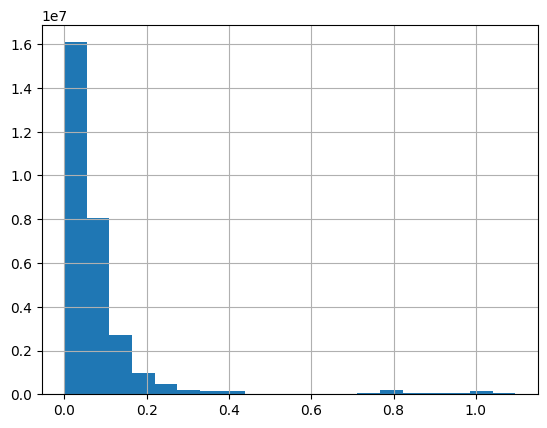

In [10]:
df["std"].hist(bins=20)

<Axes: >

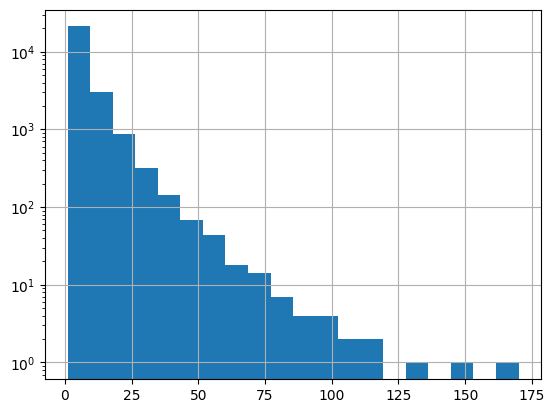

In [18]:
df[df["std"] > 1]["window_id"].value_counts().hist(bins=20,log=True)

In [72]:
results[[x[1] for x in sorted(zip(column_pos,results.columns)) if "mse" in x[1] or "paths" in x[1]]]

,paths,0.0-5.775_mse,5.775-11.55_mse,11.55-17.325000000000003_mse,17.325000000000003-23.1_mse,23.1-28.875_mse,28.875-34.650000000000006_mse,34.650000000000006-40.425000000000004_mse,40.425000000000004-46.2_mse,46.2-51.975_mse,51.975-57.75_mse
0,/sci/archive/michall/roeizucker/trained_huggin...,7.661500,87.904988,194.952672,235.833192,497.024444,609.870626,456.626711,590.804098,1338.274191,1998.013701
1,/sci/archive/michall/roeizucker/trained_huggin...,7.754282,88.027104,190.728550,221.311658,474.374958,589.641322,430.847445,569.836803,1305.299908,1969.444111
2,/sci/archive/michall/roeizucker/trained_huggin...,7.453824,86.215236,196.896816,243.920591,513.419982,621.444330,459.772883,610.975198,1366.877471,2016.976427
3,/sci/archive/michall/roeizucker/trained_huggin...,7.426579,85.903096,196.853115,244.074389,514.229588,621.371587,458.416705,612.929367,1369.844736,2016.785108
4,/sci/archive/michall/roeizucker/trained_huggin...,7.418704,85.842565,196.781256,243.954309,514.144626,621.094458,457.793900,613.147158,1370.340591,2016.717904


In [ ]:
results[[x[1] for x in sorted(zip(column_pos,results.columns)) if "pearson" in x[1] or "paths" in x[1]]]

,paths,0.0-5.775_pearsonr,5.775-11.55_pearsonr,11.55-17.325000000000003_pearsonr,17.325000000000003-23.1_pearsonr,23.1-28.875_pearsonr,28.875-34.650000000000006_pearsonr,34.650000000000006-40.425000000000004_pearsonr,40.425000000000004-46.2_pearsonr,46.2-51.975_pearsonr,51.975-57.75_pearsonr
0,/sci/archive/michall/roeizucker/trained_huggin...,0.964708,0.949263,0.893389,0.863568,0.697415,0.625997,0.723167,0.544522,0.410981,0.237725
1,/sci/archive/michall/roeizucker/trained_huggin...,0.965359,0.950480,0.894294,0.865436,0.697758,0.629978,0.729650,0.542407,0.409461,0.241197
2,/sci/archive/michall/roeizucker/trained_huggin...,0.965305,0.950443,0.895320,0.866282,0.700866,0.628778,0.729389,0.544854,0.413208,0.236804
3,/sci/archive/michall/roeizucker/trained_huggin...,0.965406,0.950689,0.895674,0.866868,0.701612,0.629717,0.730813,0.544488,0.412966,0.236543
4,/sci/archive/michall/roeizucker/trained_huggin...,0.965436,0.950751,0.895770,0.867024,0.701827,0.630022,0.731199,0.544451,0.412919,0.236511


In [ ]:
results[[x for x in sorted(results.columns) if "pearson" in x]]

,0.0-5.775_pearsonr,11.55-17.325000000000003_pearsonr,17.325000000000003-23.1_pearsonr,23.1-28.875_pearsonr,28.875-34.650000000000006_pearsonr,34.650000000000006-40.425000000000004_pearsonr,40.425000000000004-46.2_pearsonr,46.2-51.975_pearsonr,5.775-11.55_pearsonr,51.975-57.75_pearsonr
0,0.955269,0.853703,0.832576,0.656709,0.771538,0.725410,0.724786,0.444248,0.923627,0.473279
1,0.955857,0.854335,0.831921,0.658645,0.771345,0.723848,0.718102,0.437254,0.925332,0.485738
2,0.955671,0.854952,0.831596,0.657637,0.772966,0.730905,0.725443,0.447201,0.923617,0.471013
3,0.955755,0.855164,0.831354,0.657659,0.773705,0.731810,0.725003,0.448148,0.923740,0.471031
4,0.955776,0.855223,0.831300,0.657666,0.773880,0.731965,0.724903,0.448463,0.923773,0.471080


In [19]:
# import os
# import pandas as pd
# results_path = "/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/results"
# relevant = [x for x in os.listdir(results_path) if "chr5_no_lor" in x]
# for directory in relevant:
#     rel_file_path = os.path.join(directory,"resilt.csv")
#     file_path = os.path.join(results_path,rel_file_path)
#     df = pd.read_csv(file_path)
#     column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
#     df = df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "mse" in x[1] or "paths" in x[1]]]
#     df["mod"] = df["paths"].str.split("/").str[-1]
#     df = df.drop("paths",axis=1)
#     print(directory)
#     print(df)

# # df = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results/GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-1-step-83153_eval_7.5param_chr5_no_lora/resilt.csv")
# # # df = results
# # column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
# # df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "mse" in x[1] or "paths" in x[1]]].to_csv("delete_me1.csv")

In [ ]:
import pandas as pd
# prediction = predict_checkpoint(ds,ds,"regression_analysis",False,1,"InstaDeepAI","nucleotide-transformer-2.5b-multi-species","/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/GSM5652234_Liver-Hepatocytes-Z000000T3_pretrain_2.5param_chr5_no_lora_filter_variants/checkpoint-155000")
df = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results/GSM5652233_Liver-Hepatocytes-Z000000R3_epoch-1-step-83153_eval_7.5param_chr5_no_lora/resilt.csv")
# df = results
column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "pear" in x[1] or "paths" in x[1]]].to_csv("delete_me_pear_old.csv")

In [24]:
curr_df = df[[x for x in df.columns if "pearson" in x or "paths" in x]]
curr_df["stage"] = curr_df["paths"].str.split("/").str[-2:-1]
curr_df.drop("paths",axis=1)

/tmp/ipykernel_99743/3764126966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df["stage"] = curr_df["paths"].str.split("/").str[-2:-1]


,0.0-0.36533333333333334_pearsonr,0.36533333333333334-0.7306666666666667_pearsonr,0.7306666666666667-1.096_pearsonr,stage
0,0.887603,0.670099,0.305077,[GSM5652235_Liver-Hepatocytes-Z0000043Q_pretra...
1,0.891396,0.656090,0.311939,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...
2,0.894537,0.639455,0.299224,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...
3,0.886499,0.655971,0.327043,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...


In [ ]:
import pandas as pd
final_results = []
for i in range(len(results)):
    model_results = {}
    keys = []
    for bin_value in results[i]:
        bin_name = bin_value[0]
        for key in bin_value[1:]:
            key = list(key)[0]
            value = key[key]
            model_results[bin_name+"_"+key]= value
            keys.append(bin_name+"_"+key)
    final_results.append(model_results)
pd.DataFrame( final_results)

In [ ]:

from datasets import Dataset, DatasetDict, load_from_disk
import pandas as pd
import numpy as np
dataset = load_from_disk(cfg['paths']['dataset_path'])
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")
number_of_bins = 3
max_val = df["std"].max()
edges = list(np.linspace(0,max_val,number_of_bins + 1))
# labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
labels = []
for i in range(len(edges) - 1):
    labels.append(f"{edges[i]}-{edges[i+1]}")
df["std_bin"] = pd.cut(
    df["std"],                # your std-dev column
    bins=edges,
    labels=labels,
    right=True,               # (a, b]
    include_lowest=True       # include 0 in first bin
)

In [ ]:
import evaluate
pearsonr = evaluate.load("pearsonr")
mse = evaluate.load("mse")
mae = evaluate.load("mae")

In [ ]:
curr_bin = "0.0-0.36533333333333334"
curr_dataset = 0


In [ ]:
for curr_bin in df["std_bin"].unique():
    labels_from_dataset = []
    labels_from_prediction = []
    for curr_dataset in range(len(results[0].predictions)):
        curr_window_id =dataset[curr_dataset]["window_id"] 
        limited_df = df[(df["std_bin"] == curr_bin) & (df["window_id"] == curr_window_id)]
        starts_of_viable = list(limited_df["full_position"].str.split(":").str[1].str.split("-").str[0].astype(int))
        range(dataset[curr_dataset]["start"],dataset[curr_dataset]["end"])
        viable_positions = [((x//6 * 6) - dataset[curr_dataset]["start"])//6 for x in starts_of_viable ]
        filtered_labels_from_dataset = [ dataset[curr_dataset]["labels"][i + 1] for i in viable_positions]
        labels_from_dataset.extend(filtered_labels_from_dataset)
        filtered_from_prediction = [ results[0].predictions[curr_dataset][i + 1][0] for i in viable_positions]
        labels_from_prediction.extend(filtered_from_prediction)
    res_r = pearsonr.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    res_mse = mse.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    res_mae = mae.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    print(curr_bin,res_r,res_mse,res_mae)

In [ ]:
# df["std_bin"].unique
from scipy.stats import pearsonr

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_chr1_basic_test")
df_intermediate = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv")

In [ ]:
# len(set(ds["window_id"]).intersection(set(df["window_id"])))
specific_df = df[df["window_id"] == "chr1:151291800-151297200"]
labels = ds[0]["labels"]
full_position = ds[0]["full_position"]
print(len(full_position))
# df

In [ ]:
from src.utils.dataset_utils import dataset_generator_wrapper
new_dataset = Dataset.from_generator(dataset_generator_wrapper("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv", 50)) 

In [ ]:
ds[0]["labels"].count(-100)

In [ ]:
start = new_dataset[0]["start"]
for i, bin_value in enumerate(new_dataset[0]["labels"][1:]):
    if bin_value != -100:
        print(bin_value,i*6 + start)

In [ ]:
df2 = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv")

In [ ]:
df2

In [ ]:
starts_of_viable = df2[df2["window_id"] == "chr1:151291800-151297200"]["starts"][0].strip("[]").split(", ")
values = df2[df2["window_id"] == "chr1:151291800-151297200"]["values"][0].strip("[]").split(", ")
(list(zip(starts_of_viable,values)))
    

In [ ]:
# final_results = []
# # TODO: find keys without them being constants
# keys = ['eval_loss', 'eval_mse', 'eval_mae', 'eval_pearson_r', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second']
# for path,checkpoint_result in zip(cfg['paths']['model_paths'],res):
#     path_result = {"path":path}
#     for bin, eval_result in checkpoint_result:
#         for key in keys:
#             path_result[bin + key] = eval_result[key]
#             # path_result.append(eval_result[key])
#     final_results.append(path_result)
#         # print(path,bin,list(eval_result)) 
#     # print(path,checkpoint_result[0])
# final_df = pd.DataFrame(final_results) 
# final_df
results.to_csv("delete_me.csv")

In [ ]:
import pandas as pd

path = "/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/results/cpg_test_retrain_all_rows/resilt.csv"

df = pd.read_csv(path)

In [ ]:
columns_dict = {}
for col in df.columns:
    first_num = col.split("-")[0]
    if first_num not in columns_dict:
        columns_dict[first_num] = []
    columns_dict[first_num].append(col)
for key in columns_dict:
    df[columns_dict[key]].to_csv(key + "result.csv")

In [ ]:
columns_dict = {}
for col in df.columns:
    metric = (col.split(".0")[-1])
    if metric not in columns_dict:
        columns_dict[metric] = []
    columns_dict[metric].append(col)
for key in columns_dict:
    df[columns_dict[key]].to_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/"+key + "result.csv")

In [ ]:
import numpy as np
arr1 = np.linspace(0,100,4)
print(f"Array 1: {arr1}")


In [ ]:
results["checkpoint"] = results["paths"].str.strip("/").str.split('/').str[-1]
results

In [ ]:
# cfg = yaml.safe_load(open("../config_cpg_evaluation.yaml"))

analysis_name = cfg["task"]["analysis_name"]
res_path = os.path.join("results",analysis_name)
if not os.path.exists(res_path):
    os.mkdir(res_path)
results.to_csv(os.path.join(res_path,"resilt.csv"),index=None)

In [ ]:
# combine_results_section
res_path


In [ ]:
# df_combined

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

df1 = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/cpg_ENCFF713LYH_900_500m_top2000_train/resilt.csv")
df2 = pd.read_csv('/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/cpg_ENCFF713LYH_900_500m_top2000_on_ENCFF479QRW_test')
label_1 = "train"
label_2 = 'test_QRW'
df1["split"] = label_1
df2["split"] = label_2
df_combined = pd.concat([df1,df2])



df = df_combined
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Extract numeric checkpoint IDs
df["ckpt_num"] = df["checkpoint"].str.extract(r"checkpoint-(\d+)").astype(int)
df_sorted = df.sort_values("ckpt_num")

# Metrics and assigned colors
if cfg['task']["task_type"] == "cpg_evaluation":
    metrics = [("eval_pearson_r", "eval_pearson_r", "tab:blue")]
else:
    metrics = [
        ("eval_f1_class_0", "F1 Class 0", "tab:blue"),
        ("eval_f1_class_1", "F1 Class 1", "tab:orange"),
        ("eval_f1_class_2", "F1 Class 2", "tab:green"),
    ]

plt.figure(figsize=(9, 5))

for metric_col, metric_label, color in metrics:
    if metric_col not in df.columns:
        continue
    pivot = df_sorted.pivot_table(index="ckpt_num", columns="split", values=metric_col)
    if pivot.dropna(how="all").empty:
        continue
    
    # Train — solid
    if label_1 in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[label_1],
            marker="o",
            linestyle="-",
            color=color,
            label=f"{label_1} {metric_label}"
        )
        
    # Test — dotted
    if label_2 in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[label_2],
            marker="o",
            linestyle=":",
            color=color,
            label=f"{label_2} {metric_label}"
        )
plt.xlabel("Checkpoint")

if cfg['task']["task_type"] == "cpg_evaluation":
    plt.ylabel("pearson_r")
    plt.title("pearson_r over Checkpoints")
else:
    plt.ylabel("F1 Score")
    plt.title("F1 Scores (Classes 0 – 2) over Checkpoints")
plt.xticks(pivot.index, [str(x) for x in pivot.index], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# def check_predictions_for_selected_label(predictions, labels, dataset, tested_index):
#     curr_dataset = dataset.select([tested_index])
#     # to_predict = labels[tested_index] != cfg['model']['blank_label']
#     to_predict = labels[tested_index] != -100
#     predictions_masked = (predictions[tested_index].flatten()[to_predict])
#     labels_masked = labels[tested_index].flatten()[to_predict]

#     bads = 0
#     goods = 0
#     for i in range(len(predictions_masked)):
#         if abs(predictions_masked[i] - labels_masked[i]) > 10:
#             # print(f"Warning: prediction {predictions_masked[i]} does not match label {labels_masked[i]} at index {i}")
#             # print(f"Difference: {abs(predictions_masked[i] - labels_masked[i])}")
#             bads += 1
#         elif predictions_masked[i] > 30:
#             # print("good")
#             goods += 1
#     ratio = bads / (bads + goods) if (bads + goods) > 0 else 0
#     print(f"bads: {bads}, goods: {goods}, ratio: {ratio}")
#     # print(ratio)
#     # if (ratio > 0.9 or ratio < 0.1) and (bads + goods > 10):
#     #     if bads > goods:
#     #         print('bad',end=' ')
#     #     else:
#     #         print('good',end=' ')
#     #     # break
#     #     results_hist = [0]*11
#     #     for label in dataset[tested_index]["labels"]:
#     #         if label == -100:
#     #             results_hist[10]+=1
#     #             continue
#     #         index = int(label // 10)
#     #         results_hist[index] += 1
#     #     # print("hist",results_hist)
        


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])
# tested_index = 0

# # for tested_index in range(len(predictions)):
# #     check_predictions_for_selected_label(predictions, labels, dataset, tested_index)
# check_predictions_for_selected_label(predictions, labels, dataset, 2)
#     # predictions = predictions[0] if isinstance(predictions, tuple) else predictions

In [ ]:
# cfg = yaml.safe_load(open("../config_cpg_evaluation.yaml"))


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])

# tested_index = 0
# for tested_index in range(len(dataset)):
#     if tested_index % 1000 == 0:
#         print("Testing index:", tested_index,flush=True)
#     start_pos = dataset[tested_index]["start"]
#     end_pos = dataset[tested_index]["end"]
#     ranges = [
#         [3067203, 3071203],      # PRDM16 promoter/enhancer window
#         [24963138, 24967138],    # RUNX3 promoter window
#         [61080621, 61084621],    # NFIA promoter/intronic sentinel window :contentReference[oaicite:0]{index=0}
#         [65790895, 65794895],    # PDE4B promoter window :contentReference[oaicite:1]{index=1}
#         [119421765, 119425765],  # TBX15 promoter window
#         [206770494, 206774494]   # IL10 promoter window :contentReference[oaicite:2]{index=2}
#     ]
#     for val in ranges:
#         if (start_pos <= val[0] and end_pos >= val[0]) or (start_pos <= val[1] and end_pos >= val[1]) or \
#             (start_pos <= val[0] and end_pos >= val[1]) :
#             check_predictions_for_selected_label(predictions, labels, dataset, tested_index)


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])
# tested_index = 0
# for tested_index in range(0,len(dataset)):
#     if tested_index % 1000 == 0:
#         print("Testing index:", tested_index,flush=True)
#     start_pos = dataset[tested_index]["start"]
#     end_pos = dataset[tested_index]["end"]
#     if start_pos < 3067203 and start_pos > 3007203:
#         print(start_pos, end_pos)
#         print("start_pos is less than 3067203 for index:", tested_index, "start_pos:", start_pos, "end_pos:", end_pos)
        

In [ ]:
# results_hist = [0]*11
# for label in dataset[553]["labels"]:
#     if label == -100:
#         results_hist[10]+=1
#         continue
#     index = int(label // 10)
#     results_hist[index] += 1
# print(results_hist)

In [ ]:
# ranges = [
#     [3067203, 3071203],      # PRDM16 promoter/enhancer window
#     [24963138, 24967138],    # RUNX3 promoter window
#     [61080621, 61084621],    # NFIA promoter/intronic sentinel window :contentReference[oaicite:0]{index=0}
#     [65790895, 65794895],    # PDE4B promoter window :contentReference[oaicite:1]{index=1}
#     [119421765, 119425765],  # TBX15 promoter window
#     [206770494, 206774494]   # IL10 promoter window :contentReference[oaicite:2]{index=2}
# ]
# for start_pos, end_pos in zip(dataset["start"], dataset["end"]):
#     for range_val in ranges:
#         if start_pos >= range_val[0] and start_pos <= range_val[1] or \
#            end_pos >= range_val[0] and end_pos <= range_val[1] :
#             print("hit", start_pos, range_val)
    